# Variáveis Aleatórias Contínuas
### Distribuição Uniforme, Exponencial, Normal e t de Student

Continuação do notebook de [variáveis discretas](variaveis_aleatorias_discretas.ipynb).
Aqui, $X$ pode assumir qualquer valor real dentro de um intervalo, e a probabilidade de
um valor exato é sempre zero: $P(X=x)=0$. O que importa é a **área sob a curva** de uma
função densidade de probabilidade (fdp) $f(x)$ entre dois pontos:

$$P(a \leq X \leq b) = \int_a^b f(x)\, dx, \qquad \int_{-\infty}^{\infty} f(x)\, dx = 1$$

Pré-requisito: [Módulo 02 — Probabilidade](../02_Probabilidade)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({'font.size': 12})

## 1. Distribuição Uniforme

Todo valor no intervalo $[a, b]$ é igualmente provável:

$$f(x) = \frac{1}{b-a}, \quad a \leq x \leq b \qquad\qquad E(X)=\frac{a+b}{2}, \quad Var(X)=\frac{(b-a)^2}{12}$$

### Exemplo — gerador de números aleatórios

A maioria das linguagens de programação tem uma função que gera números aleatórios entre
0 e 1 com distribuição uniforme (é o que `numpy.random.uniform()` faz por baixo dos
panos). Qual a probabilidade de o número gerado cair entre 0,25 e 0,75? De ser ≤ 0,30? De
ser > 0,60?

In [2]:
a, b = 0, 1
uniforme = stats.uniform(loc=a, scale=b - a)   # scipy parametriza como (loc, loc+scale)

p1 = uniforme.cdf(0.75) - uniforme.cdf(0.25)   # P(0.25 < x < 0.75)
p2 = uniforme.cdf(0.30)                        # P(x <= 0.30)
p3 = uniforme.sf(0.60)                         # P(x > 0.60)

print(f"P(0.25 < x < 0.75) = {p1:.2%}")
print(f"P(x <= 0.30)       = {p2:.2%}")
print(f"P(x > 0.60)        = {p3:.2%}")

P(0.25 < x < 0.75) = 50.00%
P(x <= 0.30)       = 30.00%
P(x > 0.60)        = 40.00%


### Exemplo — volume de líquido em uma embalagem

Uma linha de envase enche latas com um volume que varia uniformemente entre 340 mL e
370 mL (variação normal do processo de envase). Qual o volume médio esperado e o desvio
padrão? Qual a probabilidade de uma lata sair com mais de 360 mL?

In [3]:
a2, b2 = 340, 370
dist_lata = stats.uniform(loc=a2, scale=b2 - a2)

media = dist_lata.mean()
desvio = dist_lata.std()
p_acima_360 = dist_lata.sf(360)

print(f"E(X) = {media:.2f} mL")
print(f"DP(X) = {desvio:.2f} mL")
print(f"P(X > 360) = {p_acima_360:.2%}")

E(X) = 355.00 mL
DP(X) = 8.66 mL
P(X > 360) = 33.33%


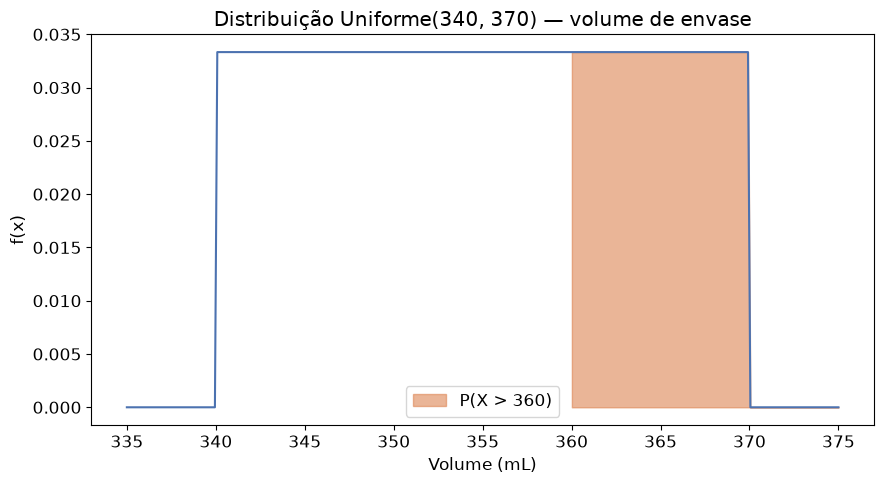

In [4]:
# Gráfico da densidade uniforme, com a área de P(X > 360) destacada
x = np.linspace(a2 - 5, b2 + 5, 300)
fx = dist_lata.pdf(x)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, fx, color='#4C72B0')
ax.fill_between(x, fx, where=(x >= 360), color='#DD8452', alpha=0.6, label='P(X > 360)')
ax.set_title('Distribuição Uniforme(340, 370) — volume de envase')
ax.set_xlabel('Volume (mL)')
ax.set_ylabel('f(x)')
ax.legend()
plt.tight_layout()
plt.savefig('img_uniforme_envase.png', dpi=110)
plt.show()

## 2. Distribuição Exponencial

Enquanto a Poisson conta **quantos** eventos ocorrem num intervalo de tempo fixo, a
Exponencial mede **quanto tempo** se espera até o próximo evento — as duas descrevem o
mesmo processo por ângulos diferentes. Se os eventos seguem Poisson com taxa $\lambda$
por unidade de tempo, o tempo até o próximo evento é Exponencial($\lambda$):

$$f(x) = \lambda e^{-\lambda x}, \quad x \geq 0 \qquad\qquad E(X) = \frac{1}{\lambda}, \quad Var(X) = \frac{1}{\lambda^2}$$

### Exemplo — tempo entre chegadas

Uma loja recebe, em média, 6 clientes por hora (processo de Poisson com
$\lambda = 6$/hora). Qual a probabilidade de o próximo cliente demorar mais de 15 minutos
(0,25 h) para chegar?

In [5]:
lam = 6  # clientes por hora
dist_exp = stats.expon(scale=1 / lam)  # scipy parametriza por escala = 1/lambda

tempo_medio_espera = dist_exp.mean() * 60       # em minutos
p_mais_15min = dist_exp.sf(15 / 60)             # 15 min = 0.25 h

print(f"Tempo médio entre chegadas: {tempo_medio_espera:.1f} min")
print(f"P(esperar mais de 15 min) = {p_mais_15min:.2%}")

Tempo médio entre chegadas: 10.0 min
P(esperar mais de 15 min) = 22.31%


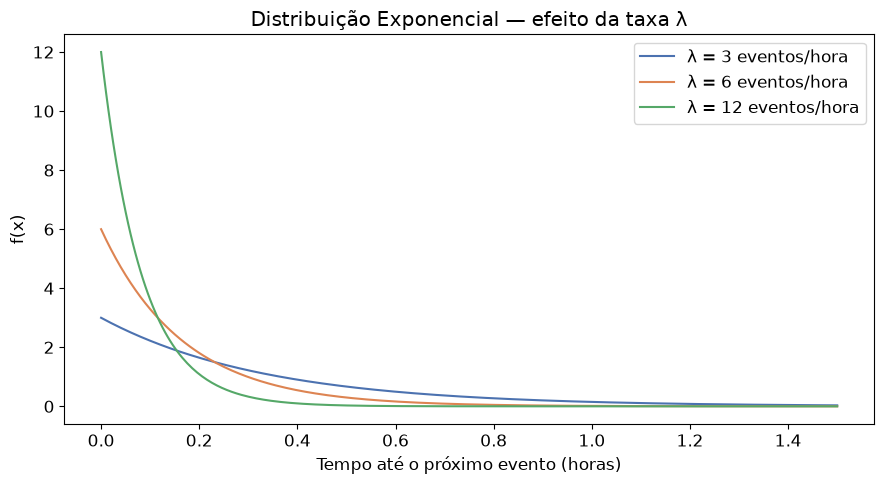

In [6]:
# Densidade exponencial e a "falta de memória": a forma da curva não muda
# se você já esperou um tempo t0 sem que o evento ocorra.
x = np.linspace(0, 1.5, 300)
fig, ax = plt.subplots(figsize=(9, 5))
for lam_i, cor in zip([3, 6, 12], ['#4C72B0', '#DD8452', '#55A868']):
    ax.plot(x, stats.expon(scale=1 / lam_i).pdf(x), color=cor,
             label=f'λ = {lam_i} eventos/hora')
ax.set_title('Distribuição Exponencial — efeito da taxa λ')
ax.set_xlabel('Tempo até o próximo evento (horas)')
ax.set_ylabel('f(x)')
ax.legend()
plt.tight_layout()
plt.savefig('img_exponencial_taxas.png', dpi=110)
plt.show()

## 3. Distribuição Normal

A mais importante das distribuições contínuas: simétrica, em forma de sino, definida por
apenas dois parâmetros ($\mu$, $\sigma$):

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

A **regra empírica** diz que, numa Normal, aproximadamente 68% dos valores caem dentro de
1 desvio padrão da média, 95% dentro de 2, e 99,7% dentro de 3.

### Exemplo — prazo de entrega

O prazo de entrega de um produto segue aproximadamente uma Normal com média de 18 dias e
desvio padrão de 4 dias: $X \sim N(18, 4^2)$. Três perguntas típicas de negócio:
qual a chance de a entrega sair em menos de 12 dias? Em mais de 21 dias? Entre 16 e 20
dias?

In [7]:
mu, sigma = 18, 4
dist_norm = stats.norm(loc=mu, scale=sigma)

p_menos_12 = dist_norm.cdf(12)
p_mais_21 = dist_norm.sf(21)
p_entre_16_20 = dist_norm.cdf(20) - dist_norm.cdf(16)

print(f"P(X < 12)        = {p_menos_12:.2%}")
print(f"P(X > 21)        = {p_mais_21:.2%}")
print(f"P(16 < X < 20)   = {p_entre_16_20:.2%}")

P(X < 12)        = 6.68%
P(X > 21)        = 22.66%
P(16 < X < 20)   = 38.29%


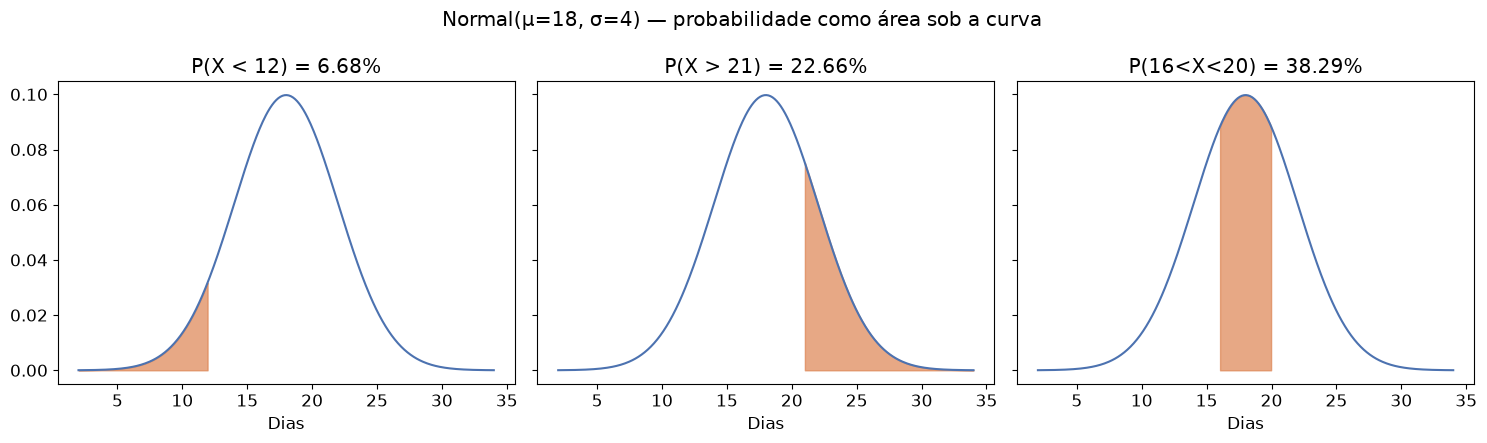

In [8]:
# As três probabilidades como área sob a curva Normal
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
fx = dist_norm.pdf(x)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

axes[0].plot(x, fx, color='#4C72B0')
axes[0].fill_between(x, fx, where=(x < 12), color='#DD8452', alpha=0.7)
axes[0].set_title(f'P(X < 12) = {p_menos_12:.2%}')

axes[1].plot(x, fx, color='#4C72B0')
axes[1].fill_between(x, fx, where=(x > 21), color='#DD8452', alpha=0.7)
axes[1].set_title(f'P(X > 21) = {p_mais_21:.2%}')

axes[2].plot(x, fx, color='#4C72B0')
axes[2].fill_between(x, fx, where=(x >= 16) & (x <= 20), color='#DD8452', alpha=0.7)
axes[2].set_title(f'P(16<X<20) = {p_entre_16_20:.2%}')

for ax in axes:
    ax.set_xlabel('Dias')
fig.suptitle('Normal(μ=18, σ=4) — probabilidade como área sob a curva')
plt.tight_layout()
plt.savefig('img_normal_prazo_entrega.png', dpi=110)
plt.show()

## 4. Distribuição t de Student

Quando o desvio padrão populacional $\sigma$ é desconhecido e precisa ser estimado a
partir do desvio padrão amostral $s$ (o caso mais comum na prática, especialmente com
amostras pequenas), a estatística

$$t = \frac{\bar{X} - \mu}{s / \sqrt{n}}$$

não segue mais exatamente uma Normal padrão — segue uma distribuição **t de Student**
com $n-1$ graus de liberdade (df). A t tem caudas mais pesadas que a Normal (reflete a
incerteza extra de estimar $\sigma$ pela amostra), e converge para a Normal padrão à
medida que $n$ cresce.

Este módulo só apresenta a distribuição em si; o uso dela para construir intervalos de
confiança fica para o [Módulo 04 — Inferência Estatística](../04_Inferência_Estatística).

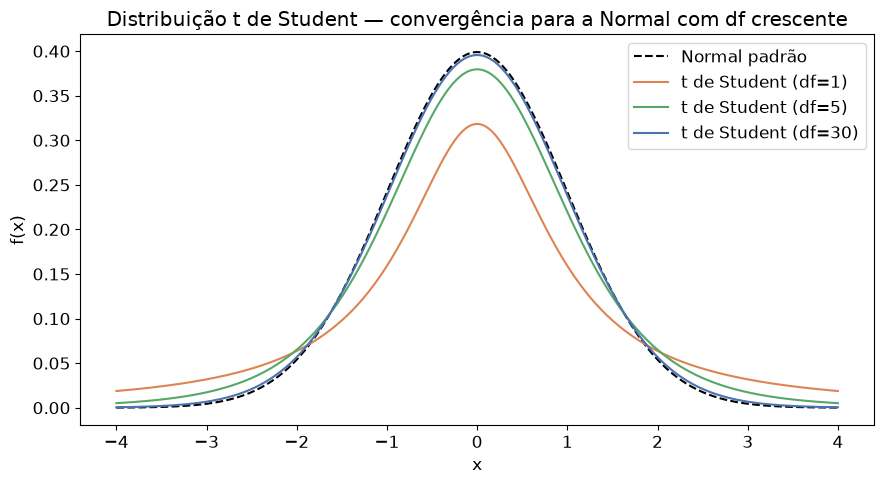

In [9]:
# Comparando a forma da t de Student com a Normal padrão, para diferentes graus de liberdade
x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, stats.norm(0, 1).pdf(x), color='black', linestyle='--', label='Normal padrão')
for df, cor in zip([1, 5, 30], ['#DD8452', '#55A868', '#4C72B0']):
    ax.plot(x, stats.t(df=df).pdf(x), color=cor, label=f't de Student (df={df})')
ax.set_title('Distribuição t de Student — convergência para a Normal com df crescente')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend()
plt.tight_layout()
plt.savefig('img_t_student_vs_normal.png', dpi=110)
plt.show()

Antes do `scipy.stats`, o valor crítico de $t$ para um dado grau de liberdade e nível
de confiança vinha de uma **tabela impressa**. Hoje, `stats.t.ppf()` faz o mesmo papel —
é a função "quantil" (inversa da acumulada): dado uma probabilidade acumulada, devolve o
valor de $t$ correspondente.

In [10]:
# Valor crítico de t para 95% de confiança (bicaudal), com amostra pequena (n=15, df=14)
df = 14
confianca = 0.95
alpha = 1 - confianca

t_critico = stats.t(df=df).ppf(1 - alpha / 2)
z_critico = stats.norm().ppf(1 - alpha / 2)

print(f"t crítico (df={df}, 95%) = {t_critico:.4f}")
print(f"z crítico (Normal, 95%)  = {z_critico:.4f}")
print("Repare que o t crítico é um pouco maior: a distribuição t é mais 'espalhada'")
print("para compensar a incerteza de estimar sigma a partir de uma amostra pequena.")

t crítico (df=14, 95%) = 2.1448
z crítico (Normal, 95%)  = 1.9600
Repare que o t crítico é um pouco maior: a distribuição t é mais 'espalhada'
para compensar a incerteza de estimar sigma a partir de uma amostra pequena.


## 5. Exercícios de fixação

1. O tempo de vida de um componente eletrônico segue uma Exponencial com média de 500
   horas. Qual a probabilidade de o componente durar mais de 800 horas?
2. As notas de uma prova seguem $N(70, 10^2)$. Qual a probabilidade de uma nota estar
   entre 60 e 85?
3. Para uma amostra de tamanho $n=25$, qual é o valor crítico de $t$ para um intervalo de
   confiança de 90%?

In [11]:
# 1. Exponencial com media 500h -> lambda = 1/500
resp1 = stats.expon(scale=500).sf(800)
print(f"1) P(X > 800h) = {resp1:.2%}")

# 2. Normal(70, 10)
resp2 = stats.norm(70, 10).cdf(85) - stats.norm(70, 10).cdf(60)
print(f"2) P(60 < nota < 85) = {resp2:.2%}")

# 3. t critico, df = 25 - 1 = 24, IC 90%
resp3 = stats.t(df=24).ppf(1 - 0.10 / 2)
print(f"3) t crítico (df=24, 90%) = {resp3:.4f}")

1) P(X > 800h) = 20.19%
2) P(60 < nota < 85) = 77.45%
3) t crítico (df=24, 90%) = 1.7109


## Encerramento do módulo

Com Uniforme, Exponencial, Normal e t de Student, o Módulo 03 está completo. O
[Módulo 04 — Inferência Estatística](../04_Inferência_Estatística) usa essas
distribuições (principalmente Normal e t) para estimar parâmetros populacionais a partir
de amostras — intervalos de confiança, tamanho de amostra e testes de hipótese.

## Bibliografia
- TRIOLA, Mario F. *Introdução à Estatística*. 8. ed. Rio de Janeiro: LTC, 2005.
- BUSSAB, Wilton O.; MORETTIN, Pedro A. *Estatística Básica*. 9. ed. São Paulo: Saraiva, 2017.
- ANDERSON, David R.; SWEENEY, Dennis J.; WILLIAMS, Thomas A. *Estatística Aplicada à Administração e Economia*. 2. ed. São Paulo: Cengage Learning, 2019.
- CASELLA, George; BERGER, Roger L. *Statistical Inference*. 2. ed. Duxbury Press, 2002.